# ARIA v5.0 — Mataian Three-Act Audit

1. 使用 Sentinel-2 L2A 影像重建馬太鞍堰塞湖三幕變化（Pre / Mid / Post）
2. 計算光譜變化指標（NDVI, BSI, NIR, SWIR）
3. 建立三種偵測遮罩（湖泊 / 崩塌 / 土石流）
4. 結合 W3–W7 成果進行多層審計分析
5. 輸出 Impact Table


套件與設定（Code）

In [1]:
# 說明：載入所有必要套件

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pystac_client import Client
import planetary_computer
import stackstac
import rioxarray

定義 BBOX

In [2]:
# gdf = gpd.read_file(r"C:\Users\vicky\Desktop\NTU\GA 遙測與空間資訊之分析與應用\windsurf-project\week8_sentinel\Lab\data\guangfu_overlay.gpkg")
# gdf = gdf.to_crs("EPSG:4326")

# bbox = gdf.total_bounds

# buffer = 0.02
MATAIAN_BBOX = [121.28, 23.56, 121.52, 23.76]

print(MATAIAN_BBOX)

[121.28, 23.56, 121.52, 23.76]


時間窗設定

In [3]:
# 定義三個時間階段

TIME_WINDOWS = {
    "pre":  ("2025-06-01", "2025-07-15"),
    "mid":  ("2025-08-01", "2025-09-20"),
    "post": ("2025-09-25", "2025-11-15")
}

STAC 連線

In [4]:
# 說明：連接 Microsoft Planetary Computer

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

搜尋影像（Pre）

In [5]:
# 說明：搜尋 Pre 時期影像

search_pre = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=MATAIAN_BBOX,
    datetime=f"{TIME_WINDOWS['pre'][0]}/{TIME_WINDOWS['pre'][1]}",
    query={"eo:cloud_cover": {"lt": 50}}
)

items_pre = list(search_pre.items())
print(len(items_pre))

4


TCI Quick QA

快速檢視影像

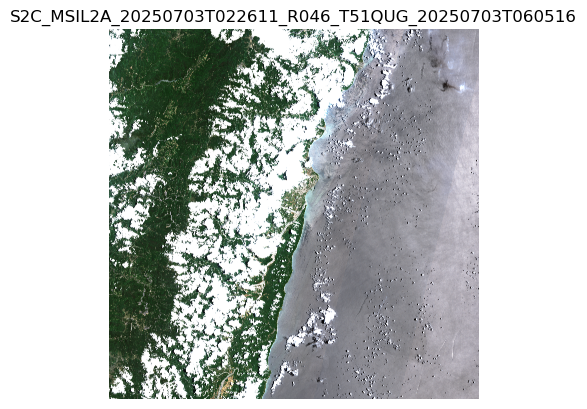

In [8]:
item = items_pre[1] 
signed = planetary_computer.sign(item.assets["visual"].href)

img = rioxarray.open_rasterio(signed)

plt.imshow(np.transpose(img.values, (1, 2, 0)))
plt.title(item.id)
plt.axis("off")
plt.show()

讀取三幕影像

In [6]:
items = list(search_pre.items())

for i, item in enumerate(items[:10]):
    print(i, item.id)

0 S2A_MSIL2A_20250705T023141_R046_T51QUG_20250705T075420
1 S2C_MSIL2A_20250703T022611_R046_T51QUG_20250703T060516
2 S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
3 S2B_MSIL2A_20250608T022529_R046_T51QUG_20250608T042638


In [7]:
# 搜尋 Med 時期影像

search_mid = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=MATAIAN_BBOX,
    datetime=f"{TIME_WINDOWS['mid'][0]}/{TIME_WINDOWS['mid'][1]}",
    query={"eo:cloud_cover": {"lt": 50}}
)

items_mid = list(search_mid.items())
print(len(items_mid))

7


In [8]:
items = list(search_mid.items())

for i, item in enumerate(items[:10]):
    print(i, item.id)

0 S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
1 S2B_MSIL2A_20250906T022529_R046_T51QUG_20250906T042640
2 S2A_MSIL2A_20250903T023141_R046_T51QUG_20250903T092313
3 S2C_MSIL2A_20250822T022611_R046_T51QUG_20250822T055915
4 S2B_MSIL2A_20250817T022539_R046_T51QUG_20250817T042827
5 S2A_MSIL2A_20250814T023131_R046_T51QUG_20250814T072515
6 S2C_MSIL2A_20250812T022551_R046_T51QUG_20250812T055213


In [9]:
# 搜尋 post 時期影像

search_post = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=MATAIAN_BBOX,
    datetime=f"{TIME_WINDOWS['post'][0]}/{TIME_WINDOWS['post'][1]}",
    query={"eo:cloud_cover": {"lt": 50}}
)

items_post = list(search_post.items())
print(len(items_post))

6


In [10]:
items = list(search_post.items())

for i, item in enumerate(items[:10]):
    print(i, item.id)

0 S2B_MSIL2A_20251115T022849_R046_T51QUG_20251115T041115
1 S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804
2 S2A_MSIL2A_20251013T023141_R046_T51QUG_20251013T083919
3 S2C_MSIL2A_20251011T022641_R046_T51QUG_20251011T061121
4 S2B_MSIL2A_20251006T022529_R046_T51QUG_20251006T042653
5 S2C_MSIL2A_20251001T022551_R046_T51QUG_20251001T055313


因為電腦效能不佳，我後來直接到 [ArcGIS Sentinel-2 Explorer](https://livingatlas.arcgis.com/sentinel2explorer/) 挑選適合分析的照片。

最後選取這三張影像：
- ![20250615](<螢幕擷取畫面 2026-04-17 194340.png>)
- ![20250817](<螢幕擷取畫面 2026-04-17 194348.png>)
- ![20251016](<螢幕擷取畫面 2026-04-17 194414.png>)


In [11]:
PRE_ITEM_ID  = "S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417"
MID_ITEM_ID  = "S2B_MSIL2A_20250817T022539_R046_T51QUG_20250817T042827"
POST_ITEM_ID = "S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804"

In [12]:
# 說明：載入選好的三張影像

def load_item(item_id):
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        ids=[item_id]
    )
    items = list(search.items())
    if not items:
        raise ValueError(f"找不到 item_id: {item_id}")

    item = planetary_computer.sign(items[0])

    stack = stackstac.stack(
        [item],
        bounds_latlon=MATAIAN_BBOX,
        assets= ["B02", "B03", "B04", "B08", "B11", "B12", "SCL"],
        epsg=32651,
        resolution=10
    )
    return stack.squeeze()

pre = load_item(PRE_ITEM_ID)
mid = load_item(MID_ITEM_ID)
post = load_item(POST_ITEM_ID)

SCL 遮罩

In [13]:
# 說明：移除雲與雲影

CLOUD_CLASSES = [3, 8, 9, 10]

def mask_clouds(data):
    scl = data.sel(band="SCL")
    mask = ~np.isin(scl, CLOUD_CLASSES)
    return data.where(mask)

pre_masked = mask_clouds(pre)
mid_masked = mask_clouds(mid)
post_masked = mask_clouds(post)

顯示 mask

c:\Users\User\anaconda3\envs\py38\lib\site-packages\matplotlib\cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


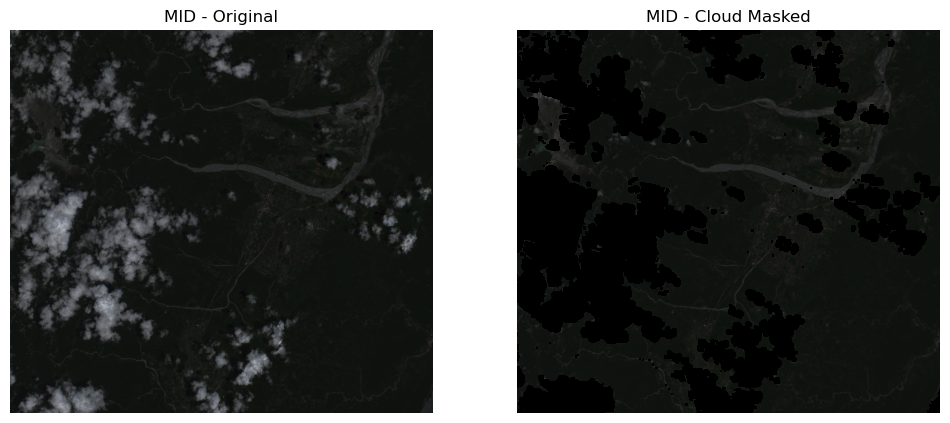

In [17]:
def show_tci(data, title):
    rgb = data.sel(band=["B04","B03","B02"]).values
    rgb = np.transpose(rgb, (1,2,0))

    # 簡單 normalize（避免過亮）
    rgb = rgb / np.nanmax(rgb)

    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    
plt.figure(figsize=(12,6))

# 原始
plt.subplot(1,2,1)
show_tci(mid, "MID - Original")
# mask 後
plt.subplot(1,2,2)
show_tci(mask_clouds(mid), "MID - Cloud Masked")

plt.show()

c:\Users\User\anaconda3\envs\py38\lib\site-packages\matplotlib\cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


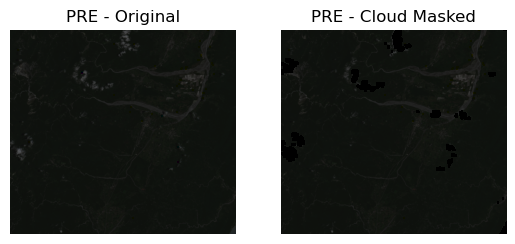

In [18]:
# 原始
plt.subplot(1,2,1)
show_tci(pre, "PRE - Original")
# mask 後
plt.subplot(1,2,2)
show_tci(pre_masked, "PRE - Cloud Masked")

plt.show()

c:\Users\User\anaconda3\envs\py38\lib\site-packages\matplotlib\cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


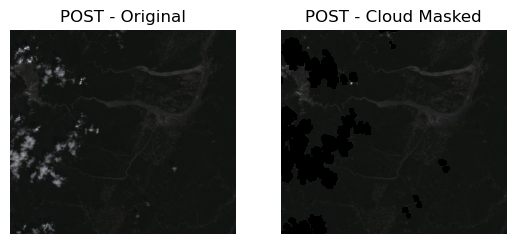

In [19]:
# 原始
plt.subplot(1,2,1)
show_tci(post, "POST - Original")
# mask 後
plt.subplot(1,2,2)
show_tci(post_masked, "POST - Cloud Masked")

plt.show()

計算指標

In [14]:
# 說明：計算 NDVI / BSI / NIR / SWIR

def compute_indices(data):
    nir = data.sel(band="B08")
    red = data.sel(band="B04")
    green = data.sel(band="B03")
    swir = data.sel(band="B11")

    ndvi = (nir - red) / (nir + red)
    bsi = ((swir + red) - (nir + green)) / ((swir + red) + (nir + green))

    return {
        "nir": nir,
        "green": green,
        "swir": swir,
        "ndvi": ndvi,
        "bsi": bsi
    }

pre_i = compute_indices(pre)
mid_i = compute_indices(mid)
post_i = compute_indices(post)

顯示指標結果

In [15]:
def show_index(index, title, cmap):
    plt.figure(figsize=(6,6))
    plt.imshow(index, cmap=cmap)
    plt.colorbar()
    plt.title(title)
    plt.axis("off")

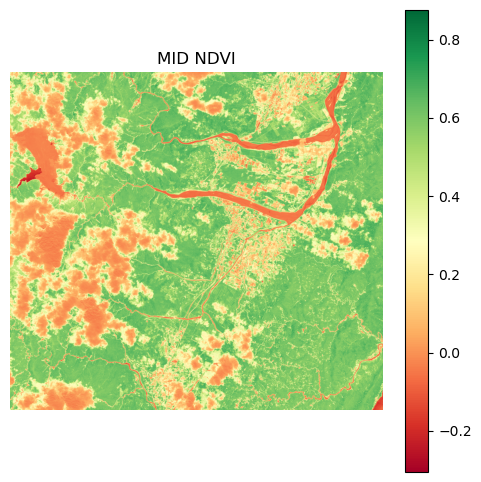

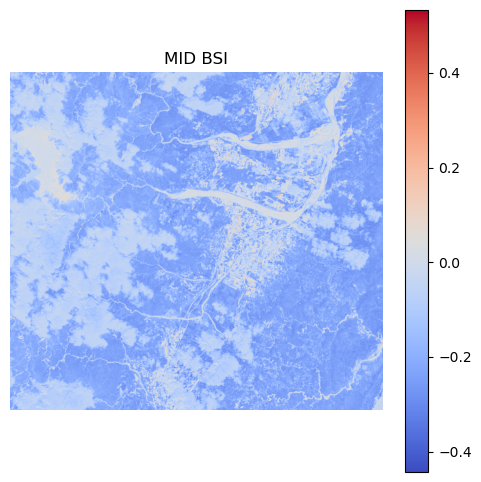

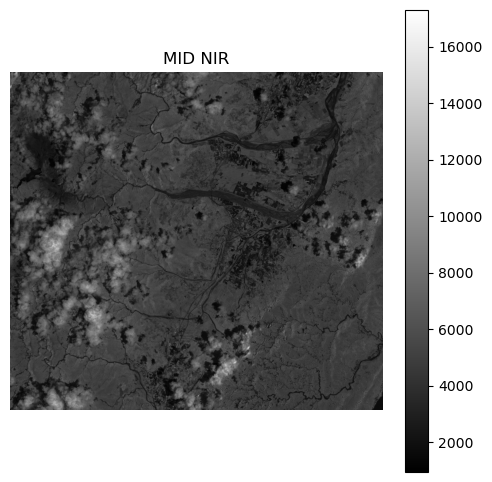

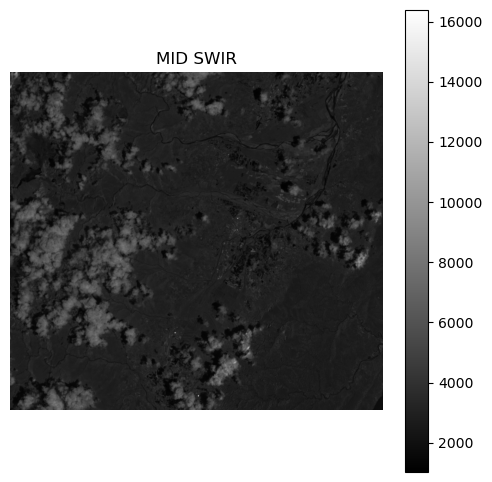

In [33]:
show_index(mid_i["ndvi"], "MID NDVI", "RdYlGn")
show_index(mid_i["bsi"], "MID BSI", "coolwarm")
show_index(mid_i["nir"], "MID NIR", "gray")
show_index(mid_i["swir"], "MID SWIR", "gray")

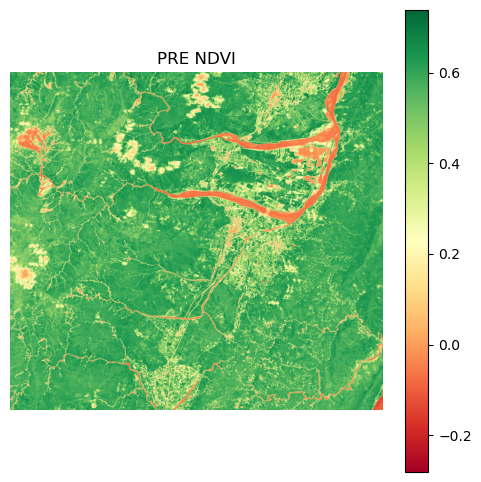

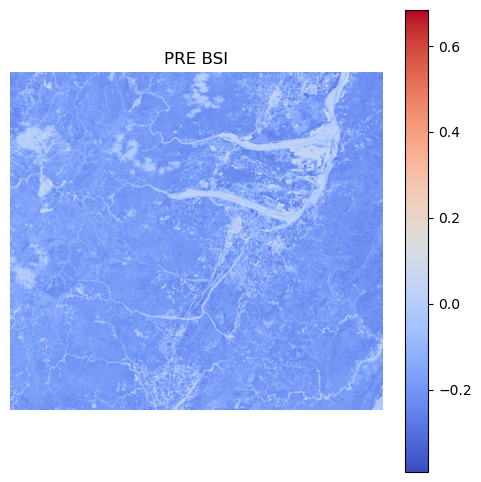

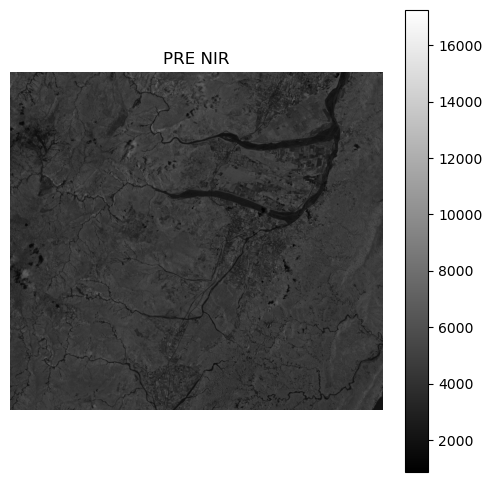

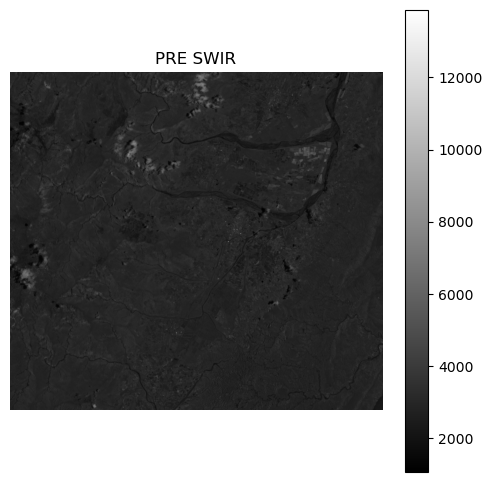

In [34]:
show_index(pre_i["ndvi"], "PRE NDVI", "RdYlGn")
show_index(pre_i["bsi"], "PRE BSI", "coolwarm")
show_index(pre_i["nir"], "PRE NIR", "gray")
show_index(pre_i["swir"], "PRE SWIR", "gray")

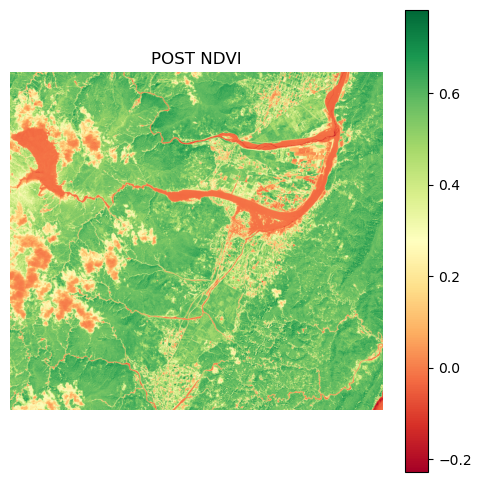

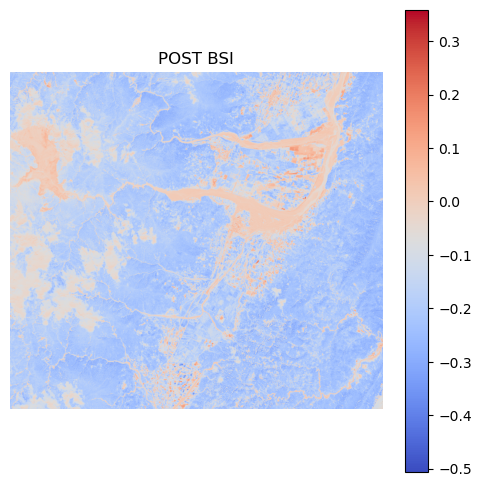

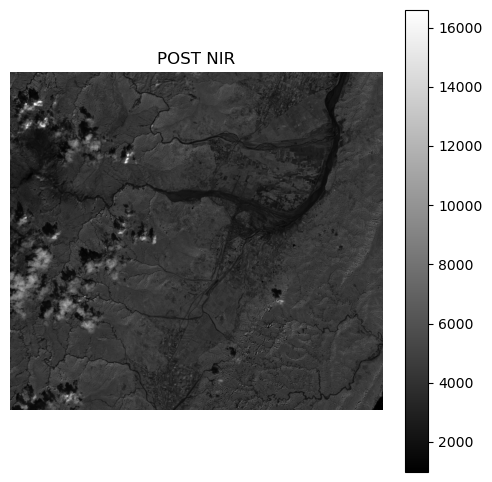

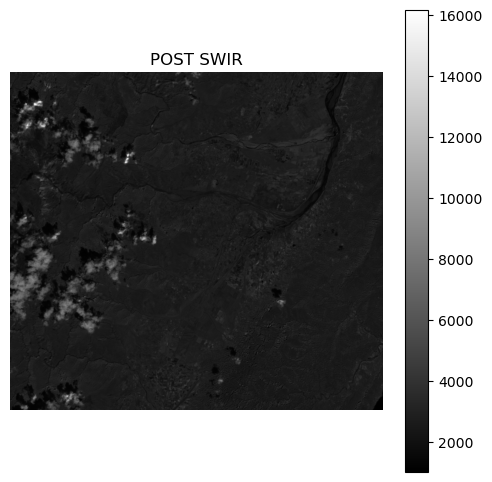

In [35]:
show_index(post_i["ndvi"], "POST NDVI", "RdYlGn")
show_index(post_i["bsi"], "POST BSI", "coolwarm")
show_index(post_i["nir"], "POST NIR", "gray")
show_index(post_i["swir"], "POST SWIR", "gray")

變化圖

In [16]:
# 說明：計算 Pre → Mid 變化

ndvi_change = mid_i["ndvi"] - pre_i["ndvi"]
bsi_change = mid_i["bsi"] - pre_i["bsi"]
nir_change = mid_i["nir"] - pre_i["nir"]

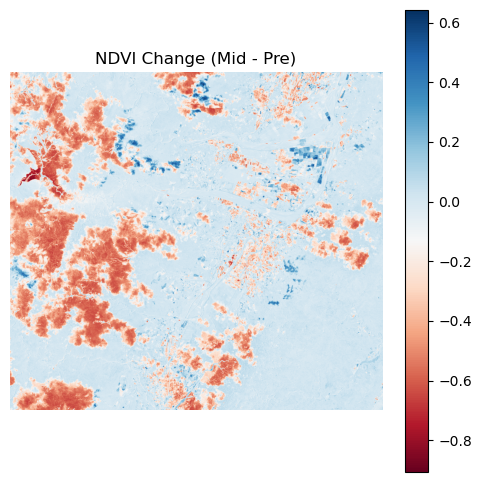

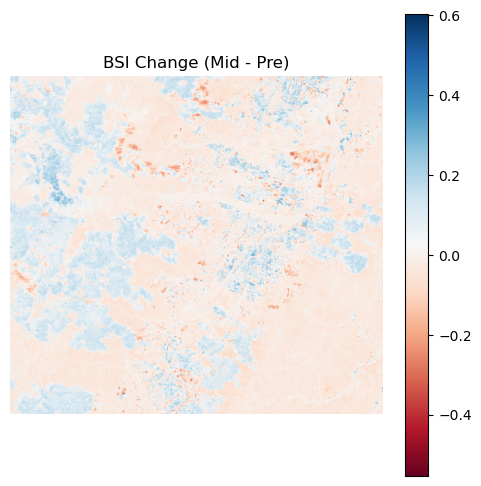

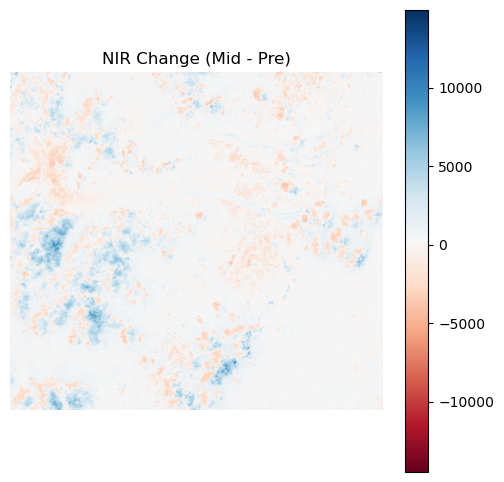

In [ ]:
show_index(ndvi_change, "NDVI Change (Mid - Pre)", "RdBu")
show_index(bsi_change, "BSI Change (Mid - Pre)", "RdBu")
show_index(nir_change, "NIR Change (Mid - Pre)", "RdBu")

湖泊偵測，嘗試後選擇(nir <= 2200)

In [27]:
# 濁水湖泊偵測

lake_mask = (
    (mid_i["nir"] <= 2200) &
    (mid_i["green"] > mid_i["nir"]) & # 確認綠光強於 NIR，符合濁水湖光譜特徵
    (mid.sel(band="B02") > 0.03) # 排除陰影區域
)


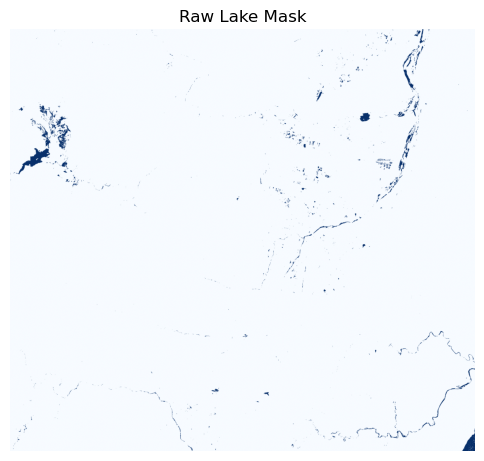

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(lake_mask, cmap="Blues")
plt.title("Raw Lake Mask")
plt.axis("off")
plt.show()

In [ ]:
# 濁水湖泊偵測

lake_mask = (
    (mid_i["nir"] <= 2200) &
    (mid_i["green"] > mid_i["nir"]) & # 確認綠光強於 NIR，符合濁水湖光譜特徵
    (mid.sel(band="B02") > 0.03) # 排除陰影區域
)

plt.figure(figsize=(6, 6))
plt.imshow(lake_mask, cmap="Blues")
plt.title("Raw Lake Mask")
plt.axis("off")
plt.show()

看 IR 假彩色影像能清楚看到湖泊位置

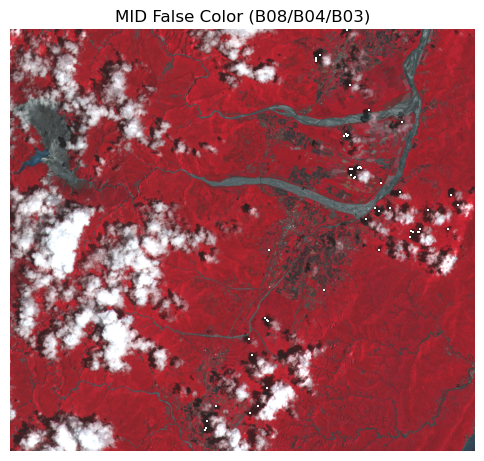

In [15]:
def show_false_color(data, title):
    rgb = data.sel(band=["B08", "B04", "B03"]).values
    rgb = np.transpose(rgb, (1, 2, 0)).astype("float32")

    rgb = rgb / np.nanpercentile(rgb, 98)
    rgb = np.clip(rgb, 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_false_color(mid, "MID False Color (B08/B04/B03)")

Cell 13 — 崩塌偵測

ground truth 選取，我是自己在 ArcGIS Sentinel-2 Explorer 手動標記的，Landslide（裸露土）、Non-landslide(森林) 各選取5個點。

In [17]:
# 崩塌條件

landslide_mask = (
    (nir_change < -0.2) &
    (mid_i["swir"] > 0.2)
)

In [18]:
import pandas as pd
import geopandas as gpd

# 說明：手動建立 ground truth（5 landslide + 5 non-landslide）
data = [
    (121.299, 23.709, 1),
    (121.384, 23.685, 1),
    (121.304, 23.692, 1),
    (121.296, 23.718, 1),
    (121.305, 23.714, 1),
    (121.337, 23.691, 0),
    (121.38, 23.696, 0),
    (121.388, 23.716, 0),
    (121.415, 23.729, 0),
    (121.374, 23.729, 0),
]

df = pd.DataFrame(data, columns=["lon", "lat", "class"])

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# 轉到 raster CRS（重要）
gdf = gdf.to_crs(pre.rio.crs)

gdf.head()

,lon,lat,class,geometry
0,121.299,23.709,1,POINT (326585.297 2623044.657)
1,121.384,23.685,1,POINT (335222.407 2620286.000)
2,121.304,23.692,1,POINT (327072.736 2621155.953)
3,121.296,23.718,1,POINT (326291.314 2624045.002)
4,121.305,23.714,1,POINT (327203.700 2623591.079)


In [19]:
# 說明：從 raster mask 取樣到點位

def sample_mask(mask, gdf):
    values = []
    for pt in gdf.geometry:
        val = mask.sel(x=pt.x, y=pt.y, method="nearest").values
        values.append(int(val))
    return values

gdf["pred"] = sample_mask(landslide_mask, gdf)

gdf

,lon,lat,class,geometry,pred
0,121.299,23.709,1,POINT (326585.297 2623044.657),1
1,121.384,23.685,1,POINT (335222.407 2620286.000),0
2,121.304,23.692,1,POINT (327072.736 2621155.953),1
3,121.296,23.718,1,POINT (326291.314 2624045.002),1
4,121.305,23.714,1,POINT (327203.700 2623591.079),1
5,121.337,23.691,0,POINT (330436.835 2621005.561),1
6,121.380,23.696,0,POINT (334828.310 2621508.765),1
7,121.388,23.716,0,POINT (335669.179 2623714.307),0
8,121.415,23.729,0,POINT (338438.126 2625123.012),0
9,121.374,23.729,0,POINT (334258.169 2625170.158),0


In [20]:
from sklearn.metrics import confusion_matrix

y_true = gdf["class"]
y_pred = gdf["pred"]

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3 2]
 [1 4]]


[[TN FP]

 [FN TP]]

In [21]:
# 計算 Precision / Recall / F1
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



Cell 14 — 土石流偵測

In [22]:
# 土石流條件

debris_mask = (
    (ndvi_change < -0.2) &
    (bsi_change > 0.1) &
    (mid.x > 121.35)   # 限制在光復下游
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00011883541295306001..2.3196672608437314].


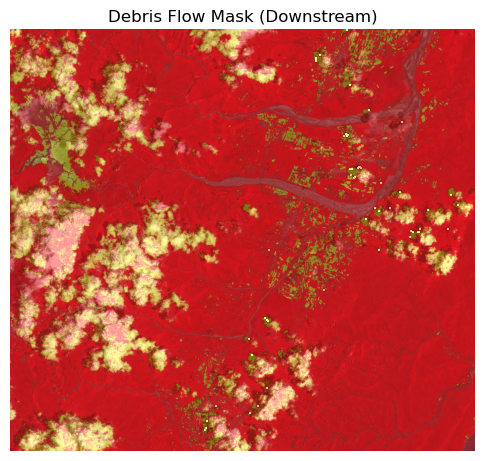

In [22]:
plt.figure(figsize=(6,6))

rgb = mid.sel(band=["B08","B04","B03"]).values
rgb = np.transpose(rgb, (1,2,0))
rgb = rgb / np.nanpercentile(rgb, 98)

plt.imshow(rgb)
plt.imshow(debris_mask, cmap="autumn", alpha=0.4)

plt.title("Debris Flow Mask (Downstream)")
plt.axis("off")
plt.show()

（前後對比）

結合前後對比影像中 NDVI 的降低和 BSI 的增加。

- NDVI 降低（`ndvi_change < -0.2`）表示地表擾動導致的植被損失。

- BSI 增加（`bsi_change > 0.1`）反映土壤和富含沉積物的地表的暴露。

此規則與滑坡檢測（C2）不同，後者使用近紅外線（NIR）訊號降低和短波紅外線（SWIR）訊號增加：

D. 多層審計 — 目擊衝擊表（Eyewitness Impact Table）

本段將整合兩類資產：

1. Guangfu overlay 中的關鍵節點  
   - 例如車站、學校、橋梁、沉積區節點
2. W3/W7 延續下來的避難所資產

對每一個資產，建立一張目擊衝擊表，記錄：
- 資產名稱
- 資產類型
- 地形風險
- 是否受堰塞湖影響
- 是否受山崩影響
- 是否受土石流影響

In [23]:
# 說明：載入 W3–W7 與 overlay

guangfu = gpd.read_file(r"D:\GA-遙測\week8_sentinel\Lab\data\guangfu_overlay.gpkg")
shelters = gpd.read_file(r"D:\GA-遙測\week8_sentinel\ARIA_v2_shelters_enhanced.gpkg")

guangfu = guangfu.to_crs(pre.rio.crs)
shelters = shelters.to_crs(pre.rio.crs)

In [24]:
print("guangfu columns:", guangfu.columns.tolist())
print("shelters columns:", shelters.columns.tolist())

guangfu columns: ['name', 'cn_name', 'node_type', 'priority', 'geometry']
shelters columns: ['shelter_id', 'name', 'capacity', 'indoor', 'river_distance_category', 'mean_elevation', 'max_slope', 'mean_slope', 'std_elevation', 'risk_level', 'geometry']


In [25]:
# 說明：統一 Guangfu 與 shelters 的欄位名稱，方便後續合併

guangfu_assets = guangfu.copy()
shelter_assets = shelters.copy()

# ---- Guangfu assets ----
guangfu_assets["asset_name"] = guangfu_assets["name"]
guangfu_assets["asset_type"] = guangfu_assets["node_type"]

# Guangfu 目前沒有直接可用的 terrain risk 欄位，先留空
guangfu_assets["terrain_risk"] = "N/A"

# 保留 priority，之後可作為補充說明
guangfu_assets["priority_level"] = guangfu_assets["priority"]

# 標記是否屬於原始 ARIA 監控範圍
guangfu_assets["covered_by_original_ARIA"] = 0

guangfu_assets = guangfu_assets[[
    "asset_name", "asset_type", "terrain_risk",
    "priority_level", "covered_by_original_ARIA", "geometry"
]].copy()

# ---- Shelter assets ----
shelter_assets["asset_name"] = shelter_assets["name"]
shelter_assets["asset_type"] = "shelter"

# shelters 可先用 risk_level 當 terrain_risk
shelter_assets["terrain_risk"] = shelter_assets["risk_level"]

# shelters 沒有 priority，就補空值
shelter_assets["priority_level"] = np.nan

# shelters 屬於原始 ARIA 系統
shelter_assets["covered_by_original_ARIA"] = 1

shelter_assets = shelter_assets[[
    "asset_name", "asset_type", "terrain_risk",
    "priority_level", "covered_by_original_ARIA", "geometry"
]].copy()

# ---- 合併 ----
assets = pd.concat([guangfu_assets, shelter_assets], ignore_index=True)
assets = gpd.GeoDataFrame(assets, geometry="geometry", crs=pre.rio.crs)

print("Total assets:", len(assets))
assets.head()

Total assets: 203


,asset_name,asset_type,terrain_risk,priority_level,covered_by_original_ARIA,geometry
0,Guangfu_Station,critical_infra,N/A,2.0,0,POINT (339234.745 2618790.238)
1,Guangfu_Elementary,shelter,N/A,1.0,0,POINT (339281.950 2618446.388)
2,Guangfu_Township_Office,shelter,N/A,1.0,0,POINT (338975.472 2618405.476)
3,Mataian_Hwy9_Bridge,bridge,N/A,1.0,0,POINT (337816.019 2615051.498)
4,Foxu_Debris_Zone,critical_infra,N/A,3.0,0,POINT (339480.079 2617912.596)


In [28]:
# 說明：將三種災害遮罩取樣到每個資產點位

def sample_mask(mask, gdf):
    values = []
    for pt in gdf.geometry:
        val = mask.sel(x=pt.x, y=pt.y, method="nearest").values
        values.append(int(bool(val)))
    return values

assets["barrier_lake_impact"] = sample_mask(lake_mask, assets)
assets["landslide_impact"] = sample_mask(landslide_mask, assets)
assets["debris_flow_impact"] = sample_mask(debris_mask, assets)

assets.head()

,asset_name,asset_type,terrain_risk,priority_level,covered_by_original_ARIA,geometry,barrier_lake_impact,landslide_impact,debris_flow_impact
0,Guangfu_Station,critical_infra,N/A,2.0,0,POINT (339234.745 2618790.238),0,1,0
1,Guangfu_Elementary,shelter,N/A,1.0,0,POINT (339281.950 2618446.388),0,1,0
2,Guangfu_Township_Office,shelter,N/A,1.0,0,POINT (338975.472 2618405.476),0,1,0
3,Mataian_Hwy9_Bridge,bridge,N/A,1.0,0,POINT (337816.019 2615051.498),0,1,0
4,Foxu_Debris_Zone,critical_infra,N/A,3.0,0,POINT (339480.079 2617912.596),0,1,0


In [29]:
# 說明：建立最終目擊衝擊表

impact_table = assets[[
    "asset_name",
    "asset_type",
    "terrain_risk",
    "priority_level",
    "covered_by_original_ARIA",
    "barrier_lake_impact",
    "landslide_impact",
    "debris_flow_impact"
]].copy()

impact_table.head()

impact_table.to_csv("eyewitness_impact_table.csv", index=False)
print("Saved: eyewitness_impact_table.csv")

Saved: eyewitness_impact_table.csv


In [30]:
# 說明：依資產類型統計各種衝擊數量

summary = impact_table.groupby("asset_type")[[
    "barrier_lake_impact",
    "landslide_impact",
    "debris_flow_impact"
]].sum()

summary

,barrier_lake_impact,landslide_impact,debris_flow_impact
asset_type,,,
bridge,0,1,0
critical_infra,0,2,0
shelter,1,130,10


In [31]:
# 說明：篩出至少受到一種災害衝擊的資產

impacted_assets = impact_table[
    (impact_table["barrier_lake_impact"] == 1) |
    (impact_table["landslide_impact"] == 1) |
    (impact_table["debris_flow_impact"] == 1)
].copy()

impacted_assets

,asset_name,asset_type,terrain_risk,priority_level,covered_by_original_ARIA,barrier_lake_impact,landslide_impact,debris_flow_impact
0,Guangfu_Station,critical_infra,N/A,2.0,0,0,1,0
1,Guangfu_Elementary,shelter,N/A,1.0,0,0,1,0
2,Guangfu_Township_Office,shelter,N/A,1.0,0,0,1,0
3,Mataian_Hwy9_Bridge,bridge,N/A,1.0,0,0,1,0
4,Foxu_Debris_Zone,critical_infra,N/A,3.0,0,0,1,0
...,...,...,...,...,...,...,...,...
198,新城社區活動中心,shelter,Low,NaN,1,0,1,0
199,興田社區活動中心,shelter,Low,NaN,1,0,1,0
200,富世活動中心,shelter,Critical,NaN,1,0,1,0
201,崇德國小收容所,shelter,High,NaN,1,0,1,0


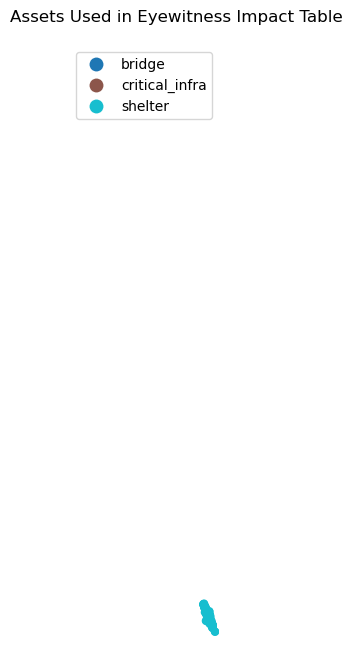

In [32]:
# 說明：在 MID 影像上顯示資產位置

fig, ax = plt.subplots(figsize=(8, 8))

rgb = mid.sel(band=["B08", "B04", "B03"]).values
rgb = np.transpose(rgb, (1, 2, 0)).astype("float32")
rgb = rgb / np.nanpercentile(rgb, 98)
rgb = np.clip(rgb, 0, 1)

ax.imshow(rgb)
assets.plot(ax=ax, markersize=25, column="asset_type", legend=True)

ax.set_title("Assets Used in Eyewitness Impact Table")
ax.axis("off")
plt.show()

Cell 16 — 取樣

In [33]:
# 說明：將 raster 結果取樣到點位

def sample_mask(mask, gdf):
    coords = [(x,y) for x,y in zip(gdf.geometry.x, gdf.geometry.y)]
    values = [mask.sel(x=x, y=y, method="nearest").values for x,y in coords]
    return values

guangfu["lake_impact"] = sample_mask(lake_mask, guangfu)
guangfu["landslide_impact"] = sample_mask(landslide_mask, guangfu)
guangfu["debris_impact"] = sample_mask(debris_mask, guangfu)

Cell 17 — Impact Table

In [34]:
# 說明：建立最終審計表

impact_table = guangfu[[
    "name",
    "lake_impact",
    "landslide_impact",
    "debris_impact"
]]

impact_table.to_csv("impact_table.csv", index=False)
impact_table.head()

,name,lake_impact,landslide_impact,debris_impact
0,Guangfu_Station,False,True,False
1,Guangfu_Elementary,False,True,False
2,Guangfu_Township_Office,False,True,False
3,Mataian_Hwy9_Bridge,False,True,False
4,Foxu_Debris_Zone,False,True,False


## 結論

1. Mid 時期成功偵測堰塞湖
2. 崩塌主要發生於上游
3. 土石流影響集中於光復下游
4. ARIA 在光復區存在覆蓋缺口

### Coverage Gap 分析
- W3/W7 未納入光復
- 網路模型忽略突發地形變化
- 缺乏即時衛星整合

### 改進建議
- 納入 Sentinel 即時監測
- 增加下游風險節點
- 動態更新網路模型